<h1><center>DL model do mnożenia dwóch liczb

<h3><center>Nikolas Kraljevic

#### Oto skrypt który tworzy, uczy i testuje model sieci neuronowej (oparty na PyTorch) do wykonywania mnożenia dwóch liczb od 1 do 100

In [1]:
# Tą linię z pip można odkomentować, jeśli potrzebujesz zainstalować PyTorch.
# Po zainstałowaniu PyTorch, możesz ponownie zakomentować, 
# albo lepiej nawet usunąć, by uniknąć ponownej instalacji przy każdym uruchomieniu notebooka.

%pip install torch torchvision

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.1 MB 2.5 MB/s eta 0:00:02
   --------------- ------------------------ 1.6/4.1 MB 2.8 MB/s eta 0:00:01
   ----------------------- ---------------- 2.4/4.1 MB 3.3 MB/s eta 0:00:01
   ----------------------------------- ---- 3.7/4.1 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 4.1/4.1 MB 4.0 MB/s  0:00:01
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
    --------------------------------------- 1.6/123.0 MB 8.2 MB/s eta 0:00:15
   - -------------------------------------- 3.4/123.0 MB 8.7 MB/s eta 0:00:14
   - -------------------------------------- 5.8/123.0 MB 9.5 MB/s eta 0:00:13
   -- ------------------------------------- 8.4/123.0 MB 10.1 MB/s eta 0:00:12
   --- ----------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\gajec\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# importy
import torch
import torch.nn as nn # modul do tworzenia sieci neuronowych
import torch.optim as optim # modul do optymalizacji wag sieci
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
print("Wszystko zainstalowane i zaimportowane!")

Wszystko zainstalowane i zaimportowane!


<h3>Najpierw potrzebujemy jakieś dane na których będziemy trenować i testować model

In [2]:
# Tworzenie zbioru danych treningowych
n_train = 8000
x_train = torch.randint(1, 101, (n_train, 2)).float()
y_train = (x_train[:, 0] * x_train[:, 1]).view(-1, 1)
print(x_train)
print(y_train)

tensor([[86., 68.],
        [71., 79.],
        [96., 52.],
        ...,
        [89., 53.],
        [88., 59.],
        [13., 18.]])
tensor([[5848.],
        [5609.],
        [4992.],
        ...,
        [4717.],
        [5192.],
        [ 234.]])


In [3]:
# Tworzenie zbioru danych testowych
n_test = 2000
x_test = torch.randint(1, 101, (n_test, 2)).float()
y_test = (x_test[:, 0] * x_test[:, 1]).view(-1, 1)

In [4]:
# Tworzenie DataLoaderów z TensorDataset do łatwego przetwarzania danych
train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### Tworzenie klasy modelu

In [5]:
# Definicja modelu sieci neuronowej
class MultiplicationNN(nn.Module):
    # Konstruktor klasy, definiuje warstwy sieci neuronowej
    def __init__(self):
        # funkcja super() służy do odwołania się do konstruktora klasy nadrzędnej 
        super(MultiplicationNN, self).__init__()
        self.layer1 = nn.Linear(2, 64)
        self.layer2 = nn.Linear(64, 64) 
        self.layer3 = nn.Linear(64, 64)   # Pierwsza warstwa, z 2 wejściami i 32 wyjściami
        self.layer4 = nn.Linear(64, 1)   # Druga warstwa, z 32 wejściami i 1 wyjściem

    # Metoda forward, określa przepływ danych przez sieć neuronową
    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = torch.relu(self.layer3(x))   # Przejście przez pierwszą warstwę z funkcją aktywacji ReLU
        x = self.layer4(x)               # Przejście przez drugą warstwę bez funkcji aktywacji
        return x                         # Zwraca wyjście z sieci

### Tworzenie konkretnej instancji modelu

In [6]:
# Inicjalizacja modelu, funkcji kosztu i optymalizatora
model = MultiplicationNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

### Trening

In [7]:
# Trenowanie modelu
n_epochs = 200
train_losses = []  # lista przechowująca wartości błędu uczenia się dla każdej epoki
for epoch in range(n_epochs):
    epoch_loss = 0
    for inputs, targets in train_loader:
        # Zerowanie gradientów
        optimizer.zero_grad()
        # Przesyłanie danych do modelu
        outputs = model(inputs)
        # Obliczanie błędu
        loss = criterion(outputs, targets)
        # Propagacja wsteczna błędu
        loss.backward()
        # Aktualizacja wag
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/200, Loss: 4608540.3005
Epoch 2/200, Loss: 762565.8520
Epoch 3/200, Loss: 431290.6161
Epoch 4/200, Loss: 412325.3702
Epoch 5/200, Loss: 392975.0536
Epoch 6/200, Loss: 367882.3359
Epoch 7/200, Loss: 339149.4006
Epoch 8/200, Loss: 299339.7405
Epoch 9/200, Loss: 241847.7178
Epoch 10/200, Loss: 192025.3650
Epoch 11/200, Loss: 130850.1126
Epoch 12/200, Loss: 87179.2687
Epoch 13/200, Loss: 54645.8397
Epoch 14/200, Loss: 36987.1865
Epoch 15/200, Loss: 22783.1749
Epoch 16/200, Loss: 13844.7462
Epoch 17/200, Loss: 10242.7078
Epoch 18/200, Loss: 9501.4835
Epoch 19/200, Loss: 6879.4254
Epoch 20/200, Loss: 6876.0218
Epoch 21/200, Loss: 4464.0519
Epoch 22/200, Loss: 3362.7446
Epoch 23/200, Loss: 3103.1277
Epoch 24/200, Loss: 3258.1630
Epoch 25/200, Loss: 2965.0348
Epoch 26/200, Loss: 2066.5335
Epoch 27/200, Loss: 1795.4103
Epoch 28/200, Loss: 1410.0437
Epoch 29/200, Loss: 1842.5042
Epoch 30/200, Loss: 1482.0564
Epoch 31/200, Loss: 4856.4590
Epoch 32/200, Loss: 1233.6272
Epoch 33/200, Loss: 

### Wizualizacja

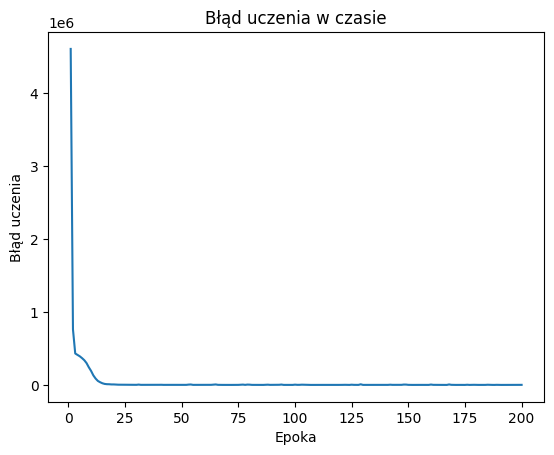

In [8]:
# Rysowanie wykresu błędu uczenia się
plt.plot(range(1, n_epochs + 1), train_losses)
plt.xlabel("Epoka")
plt.ylabel("Błąd uczenia")
plt.title("Błąd uczenia w czasie")
plt.show()

### Testowanie modelu

In [9]:
# Przetestowanie modelu na danych testowych
model.eval()
with torch.no_grad():
    test_outputs = model(x_test)
    test_loss = criterion(test_outputs, y_test)
    print(f"Test Loss: {test_loss:.4f}")

Test Loss: 4105.9917


### Porównanie testu z rzeczywysościa na wykresie

In [17]:
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\gajec\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


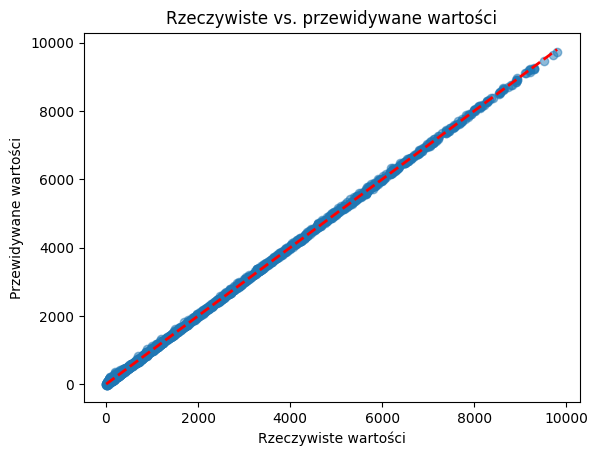

In [42]:
# Konwersja tensorów na NumPy dla rysowania wykresów
y_test_np = y_test.numpy().flatten()
test_outputs_np = test_outputs.numpy().flatten()

# Rysowanie wykresu punktowego
plt.scatter(y_test_np, test_outputs_np, alpha=0.5)
plt.xlabel("Rzeczywiste wartości")
plt.ylabel("Przewidywane wartości")
plt.title("Rzeczywiste vs. przewidywane wartości")

# Rysowanie linii identyczności (idealna predykcja)
plt.plot([min(y_test_np), max(y_test_np)], [min(y_test_np), max(y_test_np)], 'r--', lw=2)

plt.show()

### Zapisujemy model

In [ ]:
# Zapisywanie parametrów modelu do pliku
torch.save(model.state_dict(), "model_który_mnoży_dwie_liczby.pth")

### Zabawa z modelem

In [ ]:
# Teraz możemy użyć modelu do przewidywania wyników dla nowych danych
with torch.no_grad():
    while True:
        try:
            a = input("Podaj pierwszą liczbę od 1 do 100 (lub wpisz 'q', aby zakończyć): ")
            if a.lower() == 'q':
                break
            a = float(a)
            b = float(input("Podaj drugą liczbę od 1 do 100: "))
            
            if 1 <= a <= 100 and 1 <= b <= 100:
                x_new = torch.tensor([[a, b]], dtype=torch.float32)  # Przykładowe dane
                y_pred = model(x_new)
                wynik = round(y_pred.item(), 2)
                print(f"    Model uważa że {a} * {b} jest {wynik}")
                print(f"    Natomiast, prawdziwy wynik jest: {a*b} \n")
            else:
                print("Podane liczby muszą być z zakresu od 1 do 100. Spróbuj ponownie.")
        except ValueError:
            print("Błędne dane wejściowe. Spróbuj ponownie.")
        except KeyboardInterrupt:
            print("\nWychodzenie z programu.")
            break